# Pattern extraction

In [13]:
import numpy as np
import pandas as pd
import scipy as sp
import  pickle
from scipy.fft import fft
from time import localtime, strftime
import matplotlib.pyplot as plt
from skimage.morphology import  disk,remove_small_objects
from skimage.filters.rank import gradient
from skimage.util import img_as_ubyte 
import wave
import os

###########################
# Folder Name Setting
###########################

essential_folder = 'essential_data/'
supplemental_folder = 'supplemental_data/'
spectro_folder = 'spectrograms2/'
single_spectro_folder ='my_spectro_single/'
dp_folder = 'DP/'


Tue, 28 Oct 2025 13:57:16 +0000
Using 16 CPU cores
Creating spectrograms...


Spectrograms:   0%|          | 0/645 [00:00<?, ?it/s]

Tue, 28 Oct 2025 13:57:25 +0000
Extracting segments in parallel...


Segments:   0%|          | 0/645 [00:00<?, ?it/s]

Tue, 28 Oct 2025 13:57:45 +0000


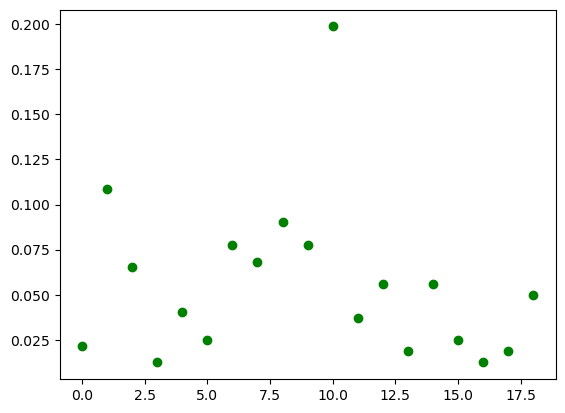

In [14]:

###################################################
## Read the Essential Data 
## labels, training-test split,file_names etc.
###################################################

# Each audio file has a unique recording identifier ("rec_id"), ranging from 0 to 644. 
# The file rec_id2filename.txt indicates which wav file is associated with each rec_id.
rec2f = pd.read_csv(essential_folder + 'rec_id2filename.txt', sep = ',')

# There are 19 bird species in the dataset. species_list.txt gives each a number from 0 to 18. 
species = pd.read_csv(essential_folder + 'species_list.txt', sep = ',')
num_species = 19

# The dataset is split into training and test sets. 
# CVfolds_2.txt gives the fold for each rec_id. 0 is the training set, and 1 is the test set.
cv =  pd.read_csv(essential_folder + 'CVfolds_2.txt', sep = ',')

# This is your main label training data. For each rec_id, a set of species is listed. The format is:
# rec_id,[labels]
raw =  pd.read_csv(essential_folder + 'rec_labels_test_hidden.txt', sep = ';')
label = np.zeros(len(raw)*num_species)
label = label.reshape([len(raw),num_species])
for i in range(len(raw)):
    line = raw.iloc[i]  # Use iloc[] instead of iloc()
    # Get the first column value and convert to string
    line_str = str(line.iloc[0]) if hasattr(line, 'iloc') else str(line[0])
    labels = line_str.split(',')
    labels.pop(0) # rec_id == i
    for c in labels:
        if(c != '?'):
            label[i,int(c)] = 1  # Convert c to int

label = pd.DataFrame(label)
label['rec_id'] = cv.rec_id
label['fold'] = cv.fold
label['filename'] = rec2f.filename

# Sparse training set 
# training species 1%--5%--20% 
spec_avg = label[label.fold ==0][range(num_species)].mean()
spec_avg.sort_values()
plt.plot(spec_avg,'go')

# Read the audio files 
# /src_wavs
# This folder contains the original wav files for the dataset (both training and test sets). 
# These are 10-second mono recordings sampled at 16kHz, 16 bits per sample.


def pic_to_ubyte (pic):
    a = (pic-np.min(pic) ) /(np.max(pic - np.min(pic))) 
    a = img_as_ubyte(a)
    return a


# Parameters to create the spectrogram
N = 160000
K = 512
Step = 4
wind =  0.5*(1 -np.cos(np.array(range(K))*2*np.pi/(K-1) ))
ffts = []


def wav_to_floats(filename):
    s = wave.open(filename,'r')
    strsig = s.readframes(s.getnframes())
    y = np.frombuffer(strsig, np.short)  # Changed from np.fromstring to np.frombuffer
    s.close()
    return y

 
###############################
## Create the Spectrograms
## Train + Test
###############################
from joblib import Parallel, delayed
import multiprocessing
from tqdm.auto import tqdm

print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))
print(f"Using {multiprocessing.cpu_count()} CPU cores")

def process_single_file(file_idx):
    """Process a single audio file to create spectrogram"""
    test_flag = label.iloc[file_idx]['fold']
    fname = label.iloc[file_idx]['filename']
    species_on_pic = []
    for n in range(num_species):
        if(label.iloc[file_idx][n] > 0):
            species_on_pic.append(n)
    
    S = wav_to_floats(essential_folder+'src_wavs/'+fname+'.wav')
    Spectogram = []
    for j in range(int(Step*N//K)-Step):  # Use integer division
        vec = S[j * K//Step : (j+Step) * K//Step] * wind
        Spectogram.append(abs(fft(vec,K)[:K//2]))
    
    return np.array(Spectogram)

# Parallel processing - uses all CPU cores with progress bar
print("Creating spectrograms...")
with tqdm(total=len(label), desc="Spectrograms") as pbar:
    ffts = []
    for result in Parallel(n_jobs=-1, return_as='generator')(
        delayed(process_single_file)(file_idx) for file_idx in range(len(label))
    ):
        ffts.append(result)
        pbar.update(1)

        
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))
SPEC_SEGMENTS = []
LOG_SPEC_SEGMENTS = []
MIN_SEGMENT_SIZE = 99
p = 90

def process_segments_for_file(file_idx):
    """Extract segments from a single file"""
    test_flag = label.iloc[file_idx]['fold']
    fname = label.iloc[file_idx]['filename']
    species_on_pic = []
    for n in range(num_species):
        if(label.iloc[file_idx][n] > 0):
            species_on_pic.append(n)
    
    label_count = label.iloc[file_idx][range(num_species)].sum()
    bird_spec = label.iloc[file_idx][range(num_species)].argmax()
    
    file_spec_segments = []
    file_log_segments = []
    
    if(test_flag < 1 and label_count == 1):
        mypic = np.transpose(ffts[file_idx])
        mypic_rev = np.flipud(mypic)  # Faster than loop
        
        mypic_rev_small = mypic_rev[:200,:]
        mypic_rev = mypic_rev_small
        mypic_rev_log = np.log10(mypic_rev + 0.001)
        mypic_rev_gauss = sp.ndimage.gaussian_filter(mypic_rev, sigma=3)
        mypic_rev_log_gauss = sp.ndimage.gaussian_filter(mypic_rev_log, sigma=3)
        mypic_rev_gauss_bin = mypic_rev_gauss > np.percentile(mypic_rev_gauss, p)
        mypic_rev_log_gauss_bin = mypic_rev_log_gauss > np.percentile(mypic_rev_log_gauss, p)
        mypic_rev_gauss_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_gauss_bin))
        mypic_rev_log_gauss_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_log_gauss_bin))
        mypic_rev_gauss_grad = gradient(pic_to_ubyte(mypic_rev_gauss), disk(3))
        mypic_rev_log_gauss_grad = gradient(pic_to_ubyte(mypic_rev_log_gauss), disk(3))
        mypic_rev_gauss_grad_bin = mypic_rev_gauss_grad > np.percentile(mypic_rev_gauss_grad, p)
        mypic_rev_log_gauss_grad_bin = mypic_rev_log_gauss_grad > np.percentile(mypic_rev_log_gauss_grad, p)
        mypic_rev_gauss_grad_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_gauss_grad_bin))
        mypic_rev_log_gauss_grad_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_log_gauss_grad_bin))
        bfh = sp.ndimage.binary_fill_holes(mypic_rev_gauss_grad_bin_close)
        bfh_rm = remove_small_objects(bfh, MIN_SEGMENT_SIZE)
        log_bfh = sp.ndimage.binary_fill_holes(mypic_rev_log_gauss_grad_bin_close)
        log_bfh_rm = remove_small_objects(log_bfh, MIN_SEGMENT_SIZE)
        
        # SEGMENTS
        labeled_segments, num_seg = sp.ndimage.label(bfh_rm)
        for current_segment_id in range(1, num_seg+1):
            current_segment = (labeled_segments == current_segment_id) * 1
            xr = current_segment.max(axis=0)
            yr = current_segment.max(axis=1)
            xr_max = np.max(xr * np.arange(len(xr)))
            xr[xr==0] = xr.shape[0]
            xr_min = np.argmin(xr)
            yr_max = np.max(yr * np.arange(len(yr)))
            yr[yr==0] = yr.shape[0]
            yr_min = np.argmin(yr)
            segment_frame = [yr_min, yr_max, xr_min, xr_max]
            subpic = mypic_rev_gauss[yr_min:yr_max+1, xr_min:xr_max+1]
            file_spec_segments.append([file_idx, current_segment_id, segment_frame, subpic])
        
        # LOG SEGMENTS
        labeled_segments, num_seg = sp.ndimage.label(log_bfh_rm)
        for current_segment_id in range(1, num_seg+1):
            current_segment = (labeled_segments == current_segment_id) * 1
            xr = current_segment.max(axis=0)
            yr = current_segment.max(axis=1)
            xr_max = np.max(xr * np.arange(len(xr)))
            xr[xr==0] = xr.shape[0]
            xr_min = np.argmin(xr)
            yr_max = np.max(yr * np.arange(len(yr)))
            yr[yr==0] = yr.shape[0]
            yr_min = np.argmin(yr)
            segment_frame = [yr_min, yr_max, xr_min, xr_max]
            subpic = mypic_rev_log_gauss[yr_min:yr_max+1, xr_min:xr_max+1]
            file_log_segments.append([file_idx, current_segment_id, segment_frame, subpic])
    
    return file_spec_segments, file_log_segments

# Parallel segment extraction
print("Extracting segments in parallel...")
with tqdm(total=len(label), desc="Segments") as pbar:
    results = []
    for result in Parallel(n_jobs=-1, return_as='generator')(
        delayed(process_segments_for_file)(file_idx) for file_idx in range(len(label))
    ):
        results.append(result)
        pbar.update(1)

# Flatten results
for spec_segs, log_segs in results:
    SPEC_SEGMENTS.extend(spec_segs)
    LOG_SPEC_SEGMENTS.extend(log_segs)        


print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

# write out the segment lists to files (create folder if needed)
# ensure the spectrogram output directory exists
os.makedirs(spectro_folder, exist_ok=True)

# save SPEC_SEGMENTS (if you want to save it too)
with open(os.path.join(spectro_folder, 'spec_segments.pkl'), 'wb') as out:
    pickle.dump(SPEC_SEGMENTS, out)

# save LOG_SPEC_SEGMENTS
with open(os.path.join(spectro_folder, 'log_spec_segments.pkl'), 'wb') as out:
    pickle.dump(LOG_SPEC_SEGMENTS, out)

# Audio Preprocessing - Noise Reduction & Bird Isolation

**Pre-processing stappen:**
1. **Spectral Subtraction**: Verwijdert achtergrondgeluid en windruis
2. **Bird Sound Isolation**: Isoleert alleen vogelgeluiden via adaptive thresholding

Deze stappen verbeteren de kwaliteit van spectrogrammen voordat ze gebruikt worden voor feature extractie.

In [15]:
###################################################
## PREPROCESSING: Spectrogram Creation met Windowing
###################################################

# Parameters voor spectrogram creatie (consistent met de rest van de pipeline)
Gebruikte_Step = 4
Gebruikte_K = 512
Gebruikte_N = 160000

def create_spectrogram(audio_signal, N=Gebruikte_N, K=Gebruikte_K, Step=Gebruikte_Step):
    """
    Maakt een spectrogram van een audio signaal met windowing
    
    Parameters:
    - audio_signal: Het audio signaal (numpy array)
    - N: Totaal aantal samples (default: 160000 = 10 sec @ 16kHz)
    - K: FFT venster grootte (512 samples)
    - Step: Hop size factor (overlapping van vensters)
    
    Returns:
    - Spectrogram als numpy array (freq, time)
    """
    # Hamming window om spectral leakage te verminderen
    window = 0.5 * (1 - np.cos(np.array(range(K)) * 2 * np.pi / (K - 1)))
    
    Spectrogram = []
    
    # Bereken aantal frames
    num_frames = int(Step * len(audio_signal) / K) - Step
    
    for j in range(num_frames):
        # Extract een frame uit het signaal
        start_idx = j * K // Step
        end_idx = (j + Step) * K // Step
        
        if end_idx <= len(audio_signal):
            vec = audio_signal[start_idx:end_idx] * window
            
            # FFT en neem alleen de positieve frequenties
            fft_result = fft(vec, K)[:K // 2]
            Spectrogram.append(np.abs(fft_result))
    
    return np.array(Spectrogram).T  # Transpose voor (freq, time) formaat

print("✓ Spectrogram functie gedefinieerd")
print(f"  K={Gebruikte_K}, Step={Gebruikte_Step}, N={Gebruikte_N}")
print(f"  Window: Hamming (reduceert spectral leakage)")

✓ Spectrogram functie gedefinieerd
  K=512, Step=4, N=160000
  Window: Hamming (reduceert spectral leakage)


In [16]:
###################################################
## PREPROCESSING: Noise Reduction via Spectral Subtraction
###################################################

# Thresholds voor noise reduction
NOISE_FRAMES = 20   # Aantal stilste frames voor ruis schatting
ALPHA = 2.0         # Over-subtraction factor (hoger = meer ruis weg)
BETA = 0.1          # Spectral floor (minimale energie na cleaning)

def reduce_noise_spectral_subtraction(audio_signal, sr=16000):
    """
    Vermindert ruis door spectral subtraction
    
    Methode:
    1. Maak spectrogram van audio signaal
    2. Vind de stilste frames (waarschijnlijk alleen ruis)
    3. Schat ruis-profiel als gemiddelde van deze frames
    4. Trek ruis af van alle frames
    5. Zet negatieve waarden op minimum niveau
    
    Parameters:
    - audio_signal: Audio samples (numpy array)
    - sr: Sample rate (default 16000 Hz)
    
    Returns:
    - cleaned_spec: Spectrogram zonder ruis
    - noise_profile: Het geschatte ruisprofiel
    """
    # Maak spectrogram
    spec = create_spectrogram(audio_signal)
    
    # Vind de stilste frames (waarschijnlijk alleen ruis)
    frame_energies = np.sum(spec, axis=0)
    noise_frame_indices = np.argsort(frame_energies)[:NOISE_FRAMES]
    
    # Schat het ruis-profiel (gemiddelde van stilste frames)
    noise_profile = np.mean(spec[:, noise_frame_indices], axis=1, keepdims=True)
    
    # Trek ruis af met over-subtraction
    cleaned_spec = spec - ALPHA * noise_profile
    
    # Zet negatieve waarden op een minimum niveau (spectral floor)
    cleaned_spec = np.maximum(cleaned_spec, BETA * spec)
    
    return cleaned_spec, noise_profile

print("✓ Noise reduction functie gedefinieerd")
print(f"  Noise frames: {NOISE_FRAMES}")
print(f"  Alpha (over-subtraction): {ALPHA}")
print(f"  Beta (spectral floor): {BETA}")

✓ Noise reduction functie gedefinieerd
  Noise frames: 20
  Alpha (over-subtraction): 2.0
  Beta (spectral floor): 0.1


In [17]:
###################################################
## PREPROCESSING: Bird Sound Isolation
###################################################

# Thresholds voor vogel segmentatie
INTENSITY_THRESHOLD_PERCENTILE = 90  # Percentile voor intensity threshold (hoger = alleen sterkste signalen)
MIN_DURATION_FRAMES = 1             # Minimale duur van een vogel signaal in frames
MEDIAN_FILTER_SIZE = 3               # Grootte van median filter voor ruis verwijdering

def isolate_bird_sounds(cleaned_spec):
    """
    Isoleer alleen de vogel geluiden uit een spectrogram door adaptive thresholding
    
    Methode:
    1. Converteer spectrogram naar dB schaal
    2. Bereken adaptive threshold per frequentie bin
    3. Maak binaire mask voor signalen boven threshold
    4. Apply median filter om kleine ruis punten te verwijderen
    5. Verwijder korte events (temporal filtering)
    6. Apply mask: alleen vogel geluiden behouden
    
    Parameters:
    - cleaned_spec: Spectrogram na noise reduction
    
    Returns:
    - bird_only_spec: Spectrogram met alleen vogelgeluiden
    - bird_mask: Binaire mask van vogel locaties
    """
    # Converteer naar dB
    spec_db = 20 * np.log10(cleaned_spec + 1e-10)
    
    # Bereken adaptive threshold per frequentie bin
    threshold = np.percentile(spec_db, INTENSITY_THRESHOLD_PERCENTILE, axis=1, keepdims=True)
    
    # Maak binaire mask: alleen waarden boven threshold
    bird_mask = spec_db > threshold
    
    # Apply median filter om kleine ruis punten te verwijderen
    from scipy.ndimage import median_filter
    bird_mask = median_filter(bird_mask.astype(float), size=(MEDIAN_FILTER_SIZE, MEDIAN_FILTER_SIZE))
    bird_mask = bird_mask > 0.5
    
    # Verwijder korte events (temporal filtering)
    for freq_idx in range(bird_mask.shape[0]):
        # Tel opeenvolgende True waarden
        counts = []
        count = 0
        for time_idx in range(bird_mask.shape[1]):
            if bird_mask[freq_idx, time_idx]:
                count += 1
            else:
                if count > 0:
                    counts.append((time_idx - count, count))
                count = 0
        if count > 0:
            counts.append((bird_mask.shape[1] - count, count))
        
        # Verwijder korte segmenten
        for start, duration in counts:
            if duration < MIN_DURATION_FRAMES:
                bird_mask[freq_idx, start:start+duration] = False
    
    # Apply mask: alleen vogel geluiden behouden, rest = 0
    bird_only_spec = np.where(bird_mask, cleaned_spec, 0)
    
    return bird_only_spec, bird_mask

print("✓ Bird sound isolation functie gedefinieerd")
print(f"  Intensity percentile: {INTENSITY_THRESHOLD_PERCENTILE}")
print(f"  Min duration: {MIN_DURATION_FRAMES} frames")
print(f"  Median filter: {MEDIAN_FILTER_SIZE}x{MEDIAN_FILTER_SIZE}")

✓ Bird sound isolation functie gedefinieerd
  Intensity percentile: 90
  Min duration: 1 frames
  Median filter: 3x3


## Test Preprocessing (Optioneel)

Uncomment de onderstaande cellen om de preprocessing te testen op een sample audio bestand.

In [18]:
# # Test preprocessing op een sample
# # Selecteer een random sample uit de training set
# sample_idx = np.random.choice(label[label.fold == 0].index)
# sample_fname = label.iloc[sample_idx]['filename']
# sample_labels = [i for i in range(num_species) if label.iloc[sample_idx][i] > 0]

# print(f"Test sample: {sample_fname}")
# print(f"Labels: {sample_labels}")

# # Laad audio
# audio_path = essential_folder + 'src_wavs/' + sample_fname + '.wav'
# S = wav_to_floats(audio_path)

# print(f"Audio loaded: {len(S)} samples ({len(S)/16000:.1f} seconds)")

# # Original spectrogram (zonder preprocessing)
# original_spec = create_spectrogram(S)

# # Met noise reduction
# cleaned_spec, noise_profile = reduce_noise_spectral_subtraction(S)

# # Met bird isolation
# bird_only_spec, bird_mask = isolate_bird_sounds(cleaned_spec)

# print(f"\nSpectrogram shapes:")
# print(f"  Original: {original_spec.shape}")
# print(f"  Cleaned: {cleaned_spec.shape}")
# print(f"  Bird only: {bird_only_spec.shape}")
# print(f"  Bird mask: {bird_mask.shape} ({bird_mask.sum()} pixels = vogels)")

In [19]:
# # Visualisatie: Vergelijk Original vs Cleaned vs Bird-only
# fig, axes = plt.subplots(4, 1, figsize=(16, 14))

# sr = 16000
# K = 512
# freqs = np.linspace(0, sr/2, K//2)
# times = np.linspace(0, len(S)/sr, original_spec.shape[1])

# # 1. Originele Spectrogram
# im1 = axes[0].imshow(20*np.log10(original_spec + 1e-10), 
#                       aspect='auto', origin='lower', cmap='viridis',
#                       extent=[0, len(S)/sr, 0, sr/2])
# axes[0].set_title(f'1. Originele Spectrogram - {sample_fname} (Labels: {sample_labels})', 
#                   fontsize=13, fontweight='bold')
# axes[0].set_xlabel('Tijd (s)')
# axes[0].set_ylabel('Frequentie (Hz)')
# axes[0].set_ylim([0, 8000])  # Focus op vogel-frequenties
# fig.colorbar(im1, ax=axes[0], label='Magnitude (dB)')

# # 2. Na Noise Reduction
# im2 = axes[1].imshow(20*np.log10(cleaned_spec + 1e-10), 
#                       aspect='auto', origin='lower', cmap='viridis',
#                       extent=[0, len(S)/sr, 0, sr/2])
# axes[1].set_title('2. Na Noise Reduction (Spectral Subtraction)', 
#                   fontsize=13, fontweight='bold')
# axes[1].set_xlabel('Tijd (s)')
# axes[1].set_ylabel('Frequentie (Hz)')
# axes[1].set_ylim([0, 8000])
# fig.colorbar(im2, ax=axes[1], label='Magnitude (dB)')

# # 3. Bird Only Spectrogram
# im3 = axes[2].imshow(20*np.log10(bird_only_spec + 1e-10), 
#                       aspect='auto', origin='lower', cmap='viridis',
#                       extent=[0, len(S)/sr, 0, sr/2])
# axes[2].set_title('3. Bird-Only Spectrogram (Adaptive Thresholding)', 
#                   fontsize=13, fontweight='bold')
# axes[2].set_xlabel('Tijd (s)')
# axes[2].set_ylabel('Frequentie (Hz)')
# axes[2].set_ylim([0, 8000])
# fig.colorbar(im3, ax=axes[2], label='Magnitude (dB)')

# # 4. Ruis profiel
# axes[3].plot(freqs, 20*np.log10(noise_profile.flatten() + 1e-10), 
#              linewidth=2, color='red', label='Geschat ruis profiel')
# axes[3].axvspan(0, 1000, alpha=0.2, color='red', label='Wind/ruis band (0-1kHz)')
# axes[3].axvspan(2000, 8000, alpha=0.2, color='green', label='Vogel band (2-8kHz)')
# axes[3].set_title('4. Geschat Ruis Profiel', fontsize=13, fontweight='bold')
# axes[3].set_xlabel('Frequentie (Hz)')
# axes[3].set_ylabel('Magnitude (dB)')
# axes[3].set_xlim([0, 8000])
# axes[3].grid(True, alpha=0.3)
# axes[3].legend()

# plt.tight_layout()
# os.makedirs('log', exist_ok=True)
# plt.savefig('log/preprocessing_comparison.png', dpi=150, bbox_inches='tight')
# plt.show()

# print("\nInterpretatie:")
# print("• Origineel: Veel laag-frequente energie (ruis, wind)")
# print("• Na noise reduction: Achtergrondgeluid verminderd")
# print("• Bird-only: Alleen vogelgeluiden behouden, rest gefilterd")
# print("• Ruis profiel: Toont welke frequenties als ruis beschouwd worden")

# data preperation

In [20]:
###################################################
# Additional imports for librosa-based features
###################################################
import librosa 
from skimage.feature import match_template

###################################################
## Parameters and Functions
###################################################

# Use same parameters as Cell 3
# K, Step, wind, essential_folder, label, SPEC_SEGMENTS are already defined

# Function to process a single file with librosa
def process_file(file_info):
    """
    Loads one audio file, creates spectrogram, and extracts features via template matching.
    """
    file_idx = file_info.name
    test_flag = file_info['fold']
    fname = file_info['filename']
    
    try:
        # Create spectrogram using librosa (faster than manual FFT)
        y, sr = librosa.load(essential_folder + 'src_wavs/' + fname + '.wav', sr=16000) 
        
        # Use librosa STFT for fast spectrogram generation
        S = np.abs(librosa.stft(y, n_fft=K, hop_length=K // Step, win_length=K, window=wind))
        
        # Take first K//2 frequency bins and transpose to (frames, freqs)
        mypic = S[:K // 2, :].T 

    except Exception as e:
        print(f"Error processing {fname} (idx {file_idx}): {e}")
        return file_idx, test_flag, None
    
    # Extract features via template matching
    mypic_rev = np.flipud(mypic)
    
    # Focus on relevant frequency domain
    mypic_rev_small = mypic_rev[:200, :]
    mypic_rev_gauss = sp.ndimage.gaussian_filter(mypic_rev_small, sigma=3)
    
    Segment_Row = []
    for s in range(len(SPEC_SEGMENTS)):
        try:
            y_min = SPEC_SEGMENTS[s][2][0]
            y_max = SPEC_SEGMENTS[s][2][1]
            segment = SPEC_SEGMENTS[s][3]
            
            # Bounds checking
            y_min_5 = max(0, y_min - 5)
            y_max_5 = min(199, y_max + 5)
            
            spectrogram_part = mypic_rev_gauss[y_min_5:y_max_5 + 1, :]
            
            # Check if segment is not larger than spectrogram_part
            if segment.shape[0] > spectrogram_part.shape[0] or \
               segment.shape[1] > spectrogram_part.shape[1]:
                Segment_Row.append(0)
                continue

            # Template matching (slowest step, but now runs in parallel)
            result = match_template(spectrogram_part, segment)
            Segment_Row.append(np.max(result))
            
        except Exception as e:
            print(f"Error in template matching (file {fname}, segment {s}): {e}")
            Segment_Row.append(0)
            
    return file_idx, test_flag, np.array(Segment_Row)

###############################################################
# PARALLEL FEATURE EXTRACTION
###############################################################
print("Start parallel feature extraction...")
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

# Use all available CPU cores with progress bar
with tqdm(total=len(label), desc="Feature extraction") as pbar:
    results = []
    for result in Parallel(n_jobs=-1, return_as='generator')(
        delayed(process_file)(row) for index, row in label.iterrows()
    ):
        results.append(result)
        pbar.update(1)

print("\nParallel processing complete.")
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

###############################################################
# SORT AND SPLIT RESULTS
###############################################################
print("Sorting and splitting results...")

# Sort results by original index to maintain correct order
results_sorted = sorted(results, key=lambda x: x[0])

TRAIN_SPEC_FEATURES = []
TEST_SPEC_FEATURES = []

for file_idx, test_flag, features in results_sorted:
    if features is not None:
        if test_flag == 0:
            TRAIN_SPEC_FEATURES.append(features)
        elif test_flag == 1:
            TEST_SPEC_FEATURES.append(features)
    else:
        print(f"Warning: No features for file index {file_idx} (likely a loading error).")

# Convert to NumPy arrays
TRAIN_SPEC_FEATURES = np.array(TRAIN_SPEC_FEATURES)
TEST_SPEC_FEATURES = np.array(TEST_SPEC_FEATURES)

print(f"Training features shape: {TRAIN_SPEC_FEATURES.shape}")
print(f"Test features shape: {TEST_SPEC_FEATURES.shape}")

###############################################################
# SAVE FEATURES
###############################################################

print("Saving training features...")
os.makedirs(dp_folder, exist_ok=True)
output = open(dp_folder + 'TRAIN_SPEC_FEATURES_freq5.pkl', 'wb')
pickle.dump(TRAIN_SPEC_FEATURES, output)
output.close()

print("Saving test features...")
output = open(dp_folder + 'TEST_SPEC_FEATURES_freq5.pkl', 'wb')
pickle.dump(TEST_SPEC_FEATURES, output)
output.close()

print("\nAll done.")
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

Start parallel feature extraction...
Tue, 28 Oct 2025 13:57:47 +0000


Feature extraction:   0%|          | 0/645 [00:00<?, ?it/s]


Parallel processing complete.
Tue, 28 Oct 2025 14:13:50 +0000
Sorting and splitting results...
Training features shape: (322, 2959)
Test features shape: (323, 2959)
Saving training features...
Saving test features...

All done.
Tue, 28 Oct 2025 14:13:50 +0000


# Data Preperation Logarithm

In [21]:
###################################################
# Additional import for this cell
###################################################
from skimage.feature import match_template

###################################################
# Reuse spectrograms from Cell 3
# Note: ffts, label, essential_folder, spectro_folder, 
#       dp_folder, LOG_SPEC_SEGMENTS are already defined
###################################################

print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))
print(f"Reusing {len(ffts)} spectrograms from Cell 3")

# Load the Logarithmic Patterns (created in Cell 3)
os.makedirs(spectro_folder, exist_ok=True)
pkl_file = open(spectro_folder + 'log_spec_segments.pkl', 'rb')
LOG_SPEC_SEGMENTS = pickle.load(pkl_file)
pkl_file.close() 

print(f"Loaded {len(LOG_SPEC_SEGMENTS)} log segments")

# Pre-filter train/test indices for efficiency
train_indices = label[label.fold == 0].index.tolist()
test_indices = label[label.fold == 1].index.tolist()

print(f"Train files: {len(train_indices)}, Test files: {len(test_indices)}")

# Pre-extract segment bounds for faster access (avoid repeated list indexing)
segment_bounds = np.array([[seg[2][0], seg[2][1]] for seg in LOG_SPEC_SEGMENTS])
segments = [seg[3] for seg in LOG_SPEC_SEGMENTS]
num_segments = len(segments)

print(f"Total template matching operations: {len(train_indices)} train + {len(test_indices)} test × {num_segments} segments")
print(f"  = {(len(train_indices) + len(test_indices)) * num_segments:,} operations")
print("Note: Template matching is computationally expensive - this will take time even with optimization")

##################
# OPTIMIZED PROCESSING FUNCTION
##################

def process_log_file(file_idx):
    """Optimized: Process a single file for logarithmic template matching"""
    # Direct array access instead of DataFrame .iloc
    mypic = np.transpose(ffts[file_idx])
    mypic_rev = np.flipud(mypic)
    
    # Focus on relevant frequency domain (200 bins)
    mypic_rev_small = mypic_rev[:200, :]
    
    # Logarithmic transformation and Gaussian filtering
    mypic_rev_log = np.log10(mypic_rev_small + 0.001)
    mypic_rev_log_gauss = sp.ndimage.gaussian_filter(mypic_rev_log, sigma=3)
    
    # Pre-allocate numpy array instead of list (faster)
    Log_Segment_Row = np.zeros(num_segments, dtype=np.float32)
    
    # Template matching loop - THIS IS THE BOTTLENECK
    # Each match_template call does a 2D convolution (very expensive)
    for s in range(num_segments):
        y_min, y_max = segment_bounds[s]
        y_min_5 = max(0, y_min - 5)
        y_max_5 = min(199, y_max + 5)
        
        spectrogram_part = mypic_rev_log_gauss[y_min_5:y_max_5+1, :]
        
        # BOTTLENECK: match_template is inherently slow (2D convolution)
        result = match_template(spectrogram_part, segments[s])
        Log_Segment_Row[s] = np.max(result)
    
    return Log_Segment_Row

##################
# TRAIN FEATURES (only process training files)
##################
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))
print("Processing training files in parallel...")

with tqdm(total=len(train_indices), desc="Train features") as pbar:
    train_results = []
    for result in Parallel(n_jobs=-1, return_as='generator')(
        delayed(process_log_file)(file_idx) for file_idx in train_indices
    ):
        train_results.append(result)
        pbar.update(1)

TRAIN_LOG_SPEC_FEATURES = np.array(train_results)
    
# SAVE THE LOG-FEATURES for the TRAINING SET
os.makedirs(dp_folder, exist_ok=True)
output = open(dp_folder + 'TRAIN_LOG_SPEC_FEATURES_freq5.pkl', 'wb')
pickle.dump(TRAIN_LOG_SPEC_FEATURES, output)
output.close() 

print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

###############################################################
# TEST FEATURES (only process test files)
###############################################################
print("Processing test files in parallel...")

with tqdm(total=len(test_indices), desc="Test features") as pbar:
    test_results = []
    for result in Parallel(n_jobs=-1, return_as='generator')(
        delayed(process_log_file)(file_idx) for file_idx in test_indices
    ):
        test_results.append(result)
        pbar.update(1)

TEST_LOG_SPEC_FEATURES = np.array(test_results)

# SAVE THE LOG-FEATURES for the TEST SET
output = open(dp_folder + 'TEST_LOG_SPEC_FEATURES_freq5.pkl', 'wb')
pickle.dump(TEST_LOG_SPEC_FEATURES, output)
output.close() 
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

Tue, 28 Oct 2025 14:13:50 +0000
Reusing 645 spectrograms from Cell 3
Loaded 3019 log segments
Train files: 322, Test files: 323
Total template matching operations: 322 train + 323 test × 3019 segments
  = 1,947,255 operations
Note: Template matching is computationally expensive - this will take time even with optimization
Tue, 28 Oct 2025 14:13:50 +0000
Processing training files in parallel...


Train features:   0%|          | 0/322 [00:00<?, ?it/s]

Tue, 28 Oct 2025 14:58:55 +0000
Processing test files in parallel...


Test features:   0%|          | 0/323 [00:00<?, ?it/s]

Tue, 28 Oct 2025 15:44:00 +0000


# Training Model (Machine Learning)

2025-10-28 15:44:01.331199: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-28 15:44:01.699067: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-28 15:44:03.806011: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-28 15:44:03.806011: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


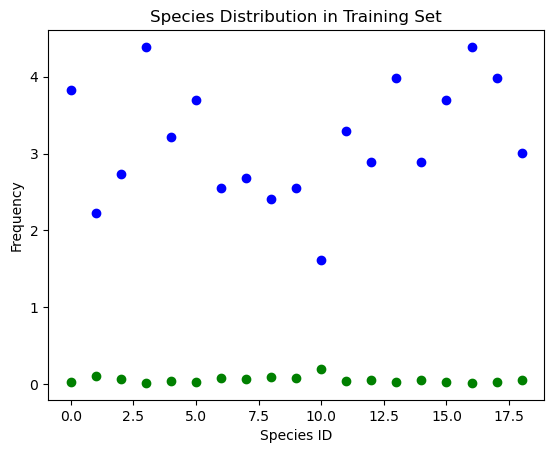

/tmp/ipykernel_25345/1872007793.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['pc'] = pc
/tmp/ipykernel_25345/1872007793.py:85: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pc'] = pc
/home/crabbedfish/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regul

NEURAL NETWORK TRAINING FOR BIRD SPECIES CLASSIFICATION

Dataset shapes:
Training features: (322, 6079)
Training labels: (322, 19)
Test features: (323, 6079)

After train/validation split:
Training: (257, 6079), Validation: (65, 6079)

MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     3,112,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,290,515 (12.55 MB)

...


Epoch 64: val_auc improved from 0.83875 to 0.84157, saving model to models/best_bird_model.h5



Epoch 65: val_auc did not improve from 0.84157

Epoch 66: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 66: val_auc did not improve from 0.84157

Epoch 66: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 66: val_auc did not improve from 0.84157

Epoch 67: val_auc did not improve from 0.84157

Epoch 67: val_auc did not improve from 0.84157

Epoch 68: val_auc did not improve from 0.84157

Epoch 68: val_auc did not improve from 0.84157

Epoch 69: val_auc did not improve from 0.84157

Epoch 69: val_auc did not improve from 0.84157

Epoch 70: val_auc improved from 0.84157 to 0.84464, saving model to models/best_bird_model.h5

Epoch 70: val_auc improved from 0.84157 to 0.84464, saving model to models/best_bird_model.h5



Epoch 71: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 71: val_auc improved from 0.84464 to 0.84610, saving model to models/best_bird_model.h5

Epoch 71: val_auc improved from 0.84464 to 0.84610, saving model to models/best_bird_model.h5



Epoch 72: val_auc did not improve from 0.84610

Epoch 73: val_auc did not improve from 0.84610

Epoch 73: val_auc did not improve from 0.84610

Epoch 74: val_auc did not improve from 0.84610

Epoch 74: val_auc did not improve from 0.84610

Epoch 75: val_auc improved from 0.84610 to 0.84680, saving model to models/best_bird_model.h5

Epoch 75: val_auc improved from 0.84610 to 0.84680, saving model to models/best_bird_model.h5



Epoch 76: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 76: val_auc did not improve from 0.84680

Epoch 76: val_auc did not improve from 0.84680

Epoch 77: val_auc did not improve from 0.84680

Epoch 77: val_auc did not improve from 0.84680

Epoch 78: val_auc did not improve from 0.84680
Epoch 78: early stopping
Restoring model weights from the end of the best epoch: 63.

Epoch 78: val_auc did not improve from 0.84680
Epoch 78: early stopping
Restoring model weights from the end of the best epoch: 63.


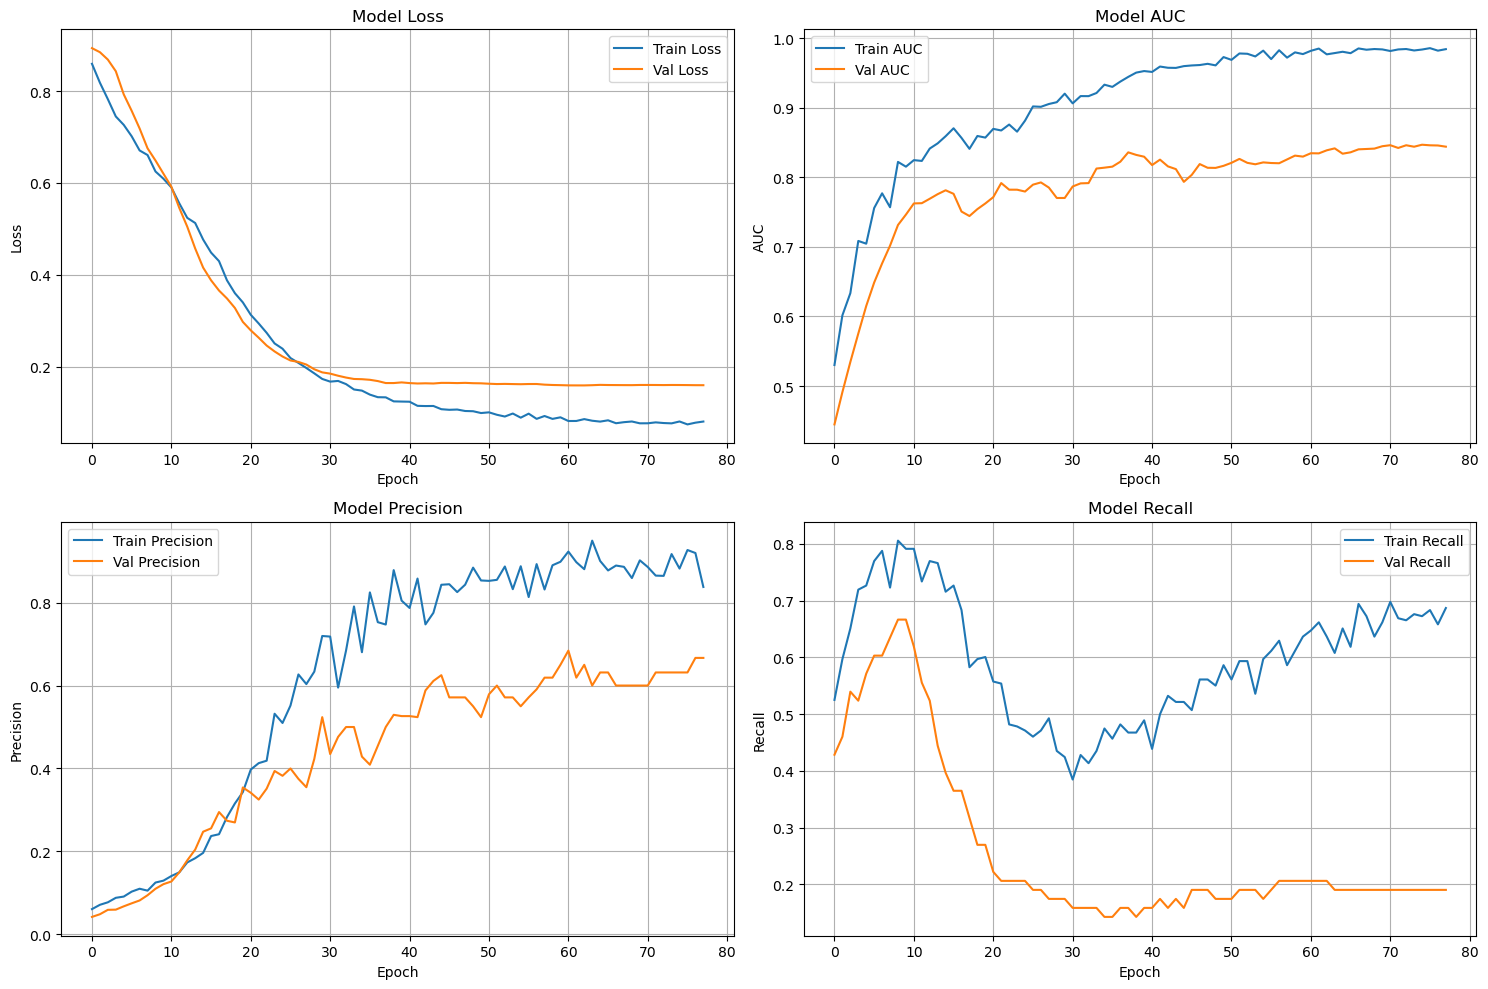


EVALUATION

Validation Results:
Loss: 0.1594
Accuracy: 0.1077
AUC: 0.8388
Precision: 0.6500
Recall: 0.2063

GENERATING PREDICTIONS
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Creating submission file...
Submission saved to: Submission/nn_bird_classification_auc0.8388.csv

TRAINING COMPLETE!
Best model saved to: models/best_bird_model.h5
Training history saved to: log/training_history.pkl
Submission file: Submission/nn_bird_classification_auc0.8388.csv

Creating submission file...
Submission saved to: Submission/nn_bird_classification_auc0.8388.csv

TRAINING COMPLETE!
Best model saved to: models/best_bird_model.h5
Training history saved to: log/training_history.pkl
Submission file: Submission/nn_bird_classification_auc0.8388.csv


In [22]:
###################################################
# Additional imports for Neural Network
###################################################
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

###########################
# Folder Name Setting
###########################
subm_folder = 'Submission/'
log_folder = 'log/'
model_folder = 'models/'

# Create folders if they don't exist
os.makedirs(dp_folder, exist_ok=True)
os.makedirs(subm_folder, exist_ok=True)
os.makedirs(log_folder, exist_ok=True)
os.makedirs(model_folder, exist_ok=True)

###################################################
## Load Essential Data (reuse from Cell 3)
## rec2f, species, num_species, cv, label are already defined
###################################################

# Visualize species distribution
spec_avg = label[label.fold ==0][range(num_species)].mean()
plt.plot(spec_avg,'go')
plt.plot(-np.log(spec_avg),'bo')
plt.title('Species Distribution in Training Set')
plt.xlabel('Species ID')
plt.ylabel('Frequency')
plt.show()

# Read histogram of segments features
hos = pd.read_csv(supplemental_folder + 'histogram_of_segments.txt', sep = ',',skiprows=1,header=0)
hos_features = ['hos_'+str(x) for x in range(100) ]
hos.columns = ['rec_id'] +hos_features

data = pd.merge(left = label, right = hos ,how = 'left', left_on = 'rec_id', right_on = 'rec_id')
data = data.fillna(0)

##############################
##          TRAIN           ##
##############################
train = data[data.fold==0]
pc = []
for i in range(len(train)):
    s = train.filename.iloc[i][:5]
    pc.append(int(s[2:s.find('_')]))  # PC1 - PC18

train['pc'] = pc

# Load spectral features
pkl_file = open(dp_folder + 'TRAIN_SPEC_FEATURES_freq5.pkl', 'rb')
tr_spec = pickle.load(pkl_file)
pkl_file.close()
spec_names = ['tr_spec_'+str(x) for x in range(tr_spec.shape[1]) ]
Spec_Df = pd.DataFrame(tr_spec, columns = spec_names)
Spec_Df['rec_id'] = train.index
train2 = pd.merge(left = train, right = Spec_Df, left_index = True, right_on = 'rec_id')

# Load logarithmic spectral features
pkl_file = open(dp_folder + 'TRAIN_LOG_SPEC_FEATURES_freq5.pkl', 'rb')
tr_log_spec = pickle.load(pkl_file)
pkl_file.close()
log_spec_names = ['tr_log_spec_'+str(x) for x in range(tr_log_spec.shape[1]) ]
Spec_Log_Df = pd.DataFrame(tr_log_spec, columns = log_spec_names)
Spec_Log_Df['rec_id'] = train.index

train3 = pd.merge(left = train2, right = Spec_Log_Df, left_on = 'rec_id', right_on = 'rec_id')

##############################
##          TEST            ##
##############################
test = data[data.fold==1]
pc = []
for i in range(len(test)):
    s = test.filename.iloc[i][:5]
    pc.append(int(s[2:s.find('_')]))  # PC1 - PC18

test['pc'] = pc

# Load test spectral features
pkl_file = open(dp_folder + 'TEST_SPEC_FEATURES_freq5.pkl', 'rb')
test_spec = pickle.load(pkl_file)
pkl_file.close()
Test_Spec_Df = pd.DataFrame(test_spec, columns = spec_names)
Test_Spec_Df['rec_id'] = test.index
test2 = pd.merge(left = test, right = Test_Spec_Df, left_index = True, right_on = 'rec_id')

# Load test logarithmic features
pkl_file = open(dp_folder + 'TEST_LOG_SPEC_FEATURES_freq5.pkl', 'rb')
test_log_spec = pickle.load(pkl_file)
pkl_file.close()
Test_Spec_Log_Df = pd.DataFrame(test_log_spec, columns = log_spec_names)
Test_Spec_Log_Df['rec_id'] = test.index

test3 = pd.merge(left = test2, right = Test_Spec_Log_Df, left_on = 'rec_id', right_on = 'rec_id')

#######################################################
## NEURAL NETWORK TRAINING                          ##
#######################################################

print("="*60)
print("NEURAL NETWORK TRAINING FOR BIRD SPECIES CLASSIFICATION")
print("="*60)

# Prepare features
feature_columns = spec_names + hos_features + ['pc'] + log_spec_names
X_train = train3[feature_columns].values
y_train = train3[range(num_species)].values
X_test = test3[feature_columns].values

print(f"\nDataset shapes:")
print(f"Training features: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test features: {X_test.shape}")

# Feature scaling - important for neural networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Split training data for validation
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

print(f"\nAfter train/validation split:")
print(f"Training: {X_train_nn.shape}, Validation: {X_val_nn.shape}")

# Build Neural Network
def create_bird_classifier(input_dim, num_classes):
    """
    Creates a deep neural network for multi-label bird species classification
    """
    model = keras.Sequential([
        # Input layer
        layers.Dense(512, activation='relu', input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        
        # Hidden layers
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        # Output layer - sigmoid for multi-label classification
        layers.Dense(num_classes, activation='sigmoid')
    ])
    
    return model

# Create model
model = create_bird_classifier(X_train_scaled.shape[1], num_species)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # For multi-label classification
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# Model summary
print("\n" + "="*60)
print("MODEL ARCHITECTURE")
print("="*60)
model.summary()

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    model_folder + 'best_bird_model.h5',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Custom callback for progress bar
class TqdmCallback(callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epochs = self.params['epochs']
        self.pbar = tqdm(total=self.epochs, desc='Training')
    
    def on_epoch_end(self, epoch, logs=None):
        self.pbar.update(1)
        self.pbar.set_postfix({
            'loss': f"{logs['loss']:.4f}",
            'val_loss': f"{logs['val_loss']:.4f}",
            'auc': f"{logs['auc']:.4f}",
            'val_auc': f"{logs['val_auc']:.4f}"
        })
    
    def on_train_end(self, logs=None):
        self.pbar.close()

tqdm_callback = TqdmCallback()

# Train the model
print("\n" + "="*60)
print("TRAINING")
print("="*60)

history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, model_checkpoint, tqdm_callback],
    verbose=0  # We use tqdm for progress
)

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# AUC
axes[0, 1].plot(history.history['auc'], label='Train AUC')
axes[0, 1].plot(history.history['val_auc'], label='Val AUC')
axes[0, 1].set_title('Model AUC')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train Precision')
axes[1, 0].plot(history.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Model Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train Recall')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Model Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(log_folder + 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("EVALUATION")
print("="*60)

# Evaluate on validation set
val_results = model.evaluate(X_val_nn, y_val_nn, verbose=0)
print(f"\nValidation Results:")
print(f"Loss: {val_results[0]:.4f}")
print(f"Accuracy: {val_results[1]:.4f}")
print(f"AUC: {val_results[2]:.4f}")
print(f"Precision: {val_results[3]:.4f}")
print(f"Recall: {val_results[4]:.4f}")

# Make predictions on test set
print("\n" + "="*60)
print("GENERATING PREDICTIONS")
print("="*60)

test_predictions = model.predict(X_test_scaled, batch_size=32, verbose=1)

# Create submission file
print("\nCreating submission file...")
Submission_ID = []
Submission_PROB = []

for bird in range(num_species):
    ids = np.array(test3.rec_id) * 100 + bird
    probs = test_predictions[:, bird]
    Submission_ID.extend(list(ids))
    Submission_PROB.extend(list(probs))

SubmissionDf = pd.DataFrame({
    'Id': Submission_ID,
    'Probability': Submission_PROB
})

submission_filename = subm_folder + f'nn_bird_classification_auc{val_results[2]:.4f}.csv'
SubmissionDf.to_csv(submission_filename, index=False)
print(f"Submission saved to: {submission_filename}")

# Save training history
history_dict = {
    'loss': history.history['loss'],
    'val_loss': history.history['val_loss'],
    'auc': history.history['auc'],
    'val_auc': history.history['val_auc'],
    'precision': history.history['precision'],
    'val_precision': history.history['val_precision'],
    'recall': history.history['recall'],
    'val_recall': history.history['val_recall']
}

with open(log_folder + 'training_history.pkl', 'wb') as f:
    pickle.dump(history_dict, f)

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print(f"Best model saved to: {model_folder}best_bird_model.h5")
print(f"Training history saved to: {log_folder}training_history.pkl")
print(f"Submission file: {submission_filename}")

# pipeline test

Visualiseren van data preparation voor 5 vogel samples


SAMPLE 1/5 - File Index: 186
Bestand: PC2_20100513_043000_0730
Vogelsoort ID: 1
Aantal gedetecteerde segmenten: 49
Aantal gedetecteerde segmenten: 49


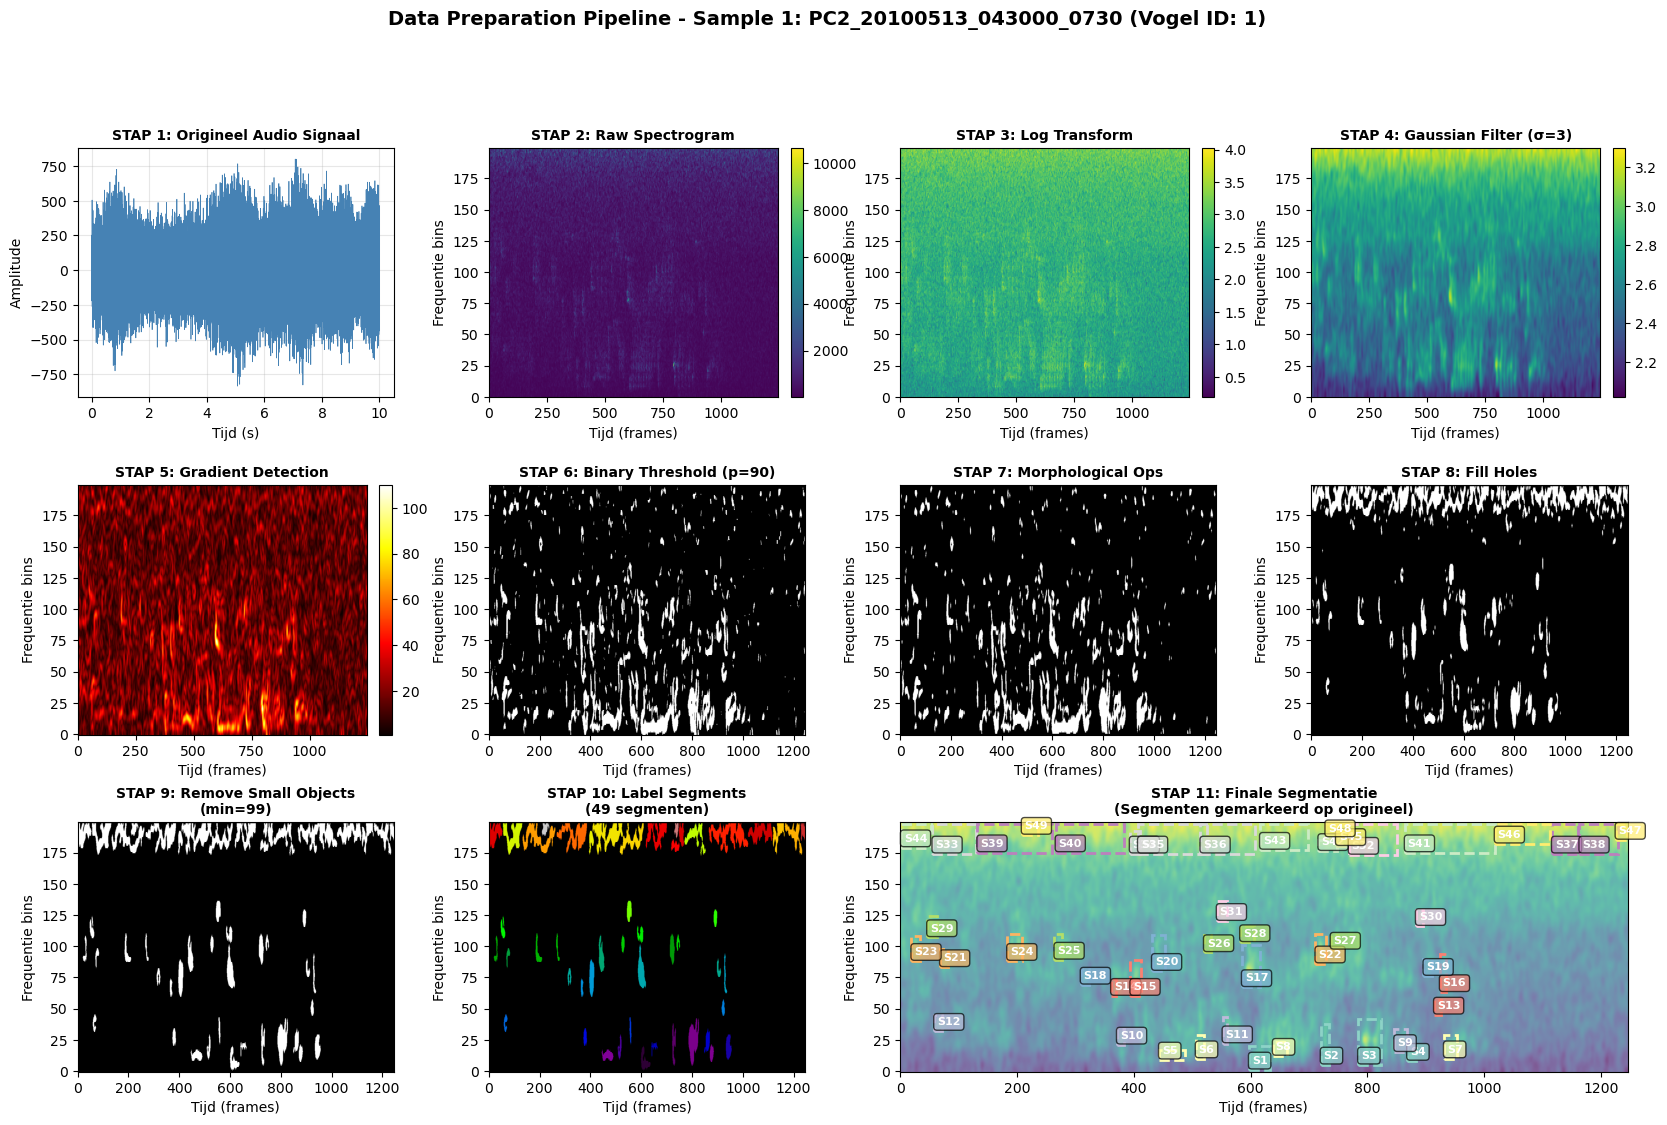


Segment Details:
  Segment 1: Positie=(597-634, 1-20), Grootte=(37x19), Area=703 pixels
  Segment 2: Positie=(720-734, 5-38), Grootte=(14x33), Area=462 pixels
  Segment 3: Positie=(784-824, 5-42), Grootte=(40x37), Area=1480 pixels
  Segment 4: Positie=(868-883, 8-21), Grootte=(15x13), Area=195 pixels
  Segment 5: Positie=(443-488, 9-17), Grootte=(45x8), Area=360 pixels
  Segment 6: Positie=(506-520, 10-29), Grootte=(14x19), Area=266 pixels
  Segment 7: Positie=(931-953, 10-29), Grootte=(22x19), Area=418 pixels
  Segment 8: Positie=(638-662, 12-23), Grootte=(24x11), Area=264 pixels
  Segment 9: Positie=(846-867, 15-34), Grootte=(21x19), Area=399 pixels
  Segment 10: Positie=(371-384, 21-34), Grootte=(13x13), Area=169 pixels
  Segment 11: Positie=(552-559, 22-43), Grootte=(7x21), Area=147 pixels
  Segment 12: Positie=(58-72, 32-45), Grootte=(14x13), Area=182 pixels
  Segment 13: Positie=(914-926, 45-57), Grootte=(12x12), Area=144 pixels
  Segment 14: Positie=(361-370, 60-74), Grootte=(9

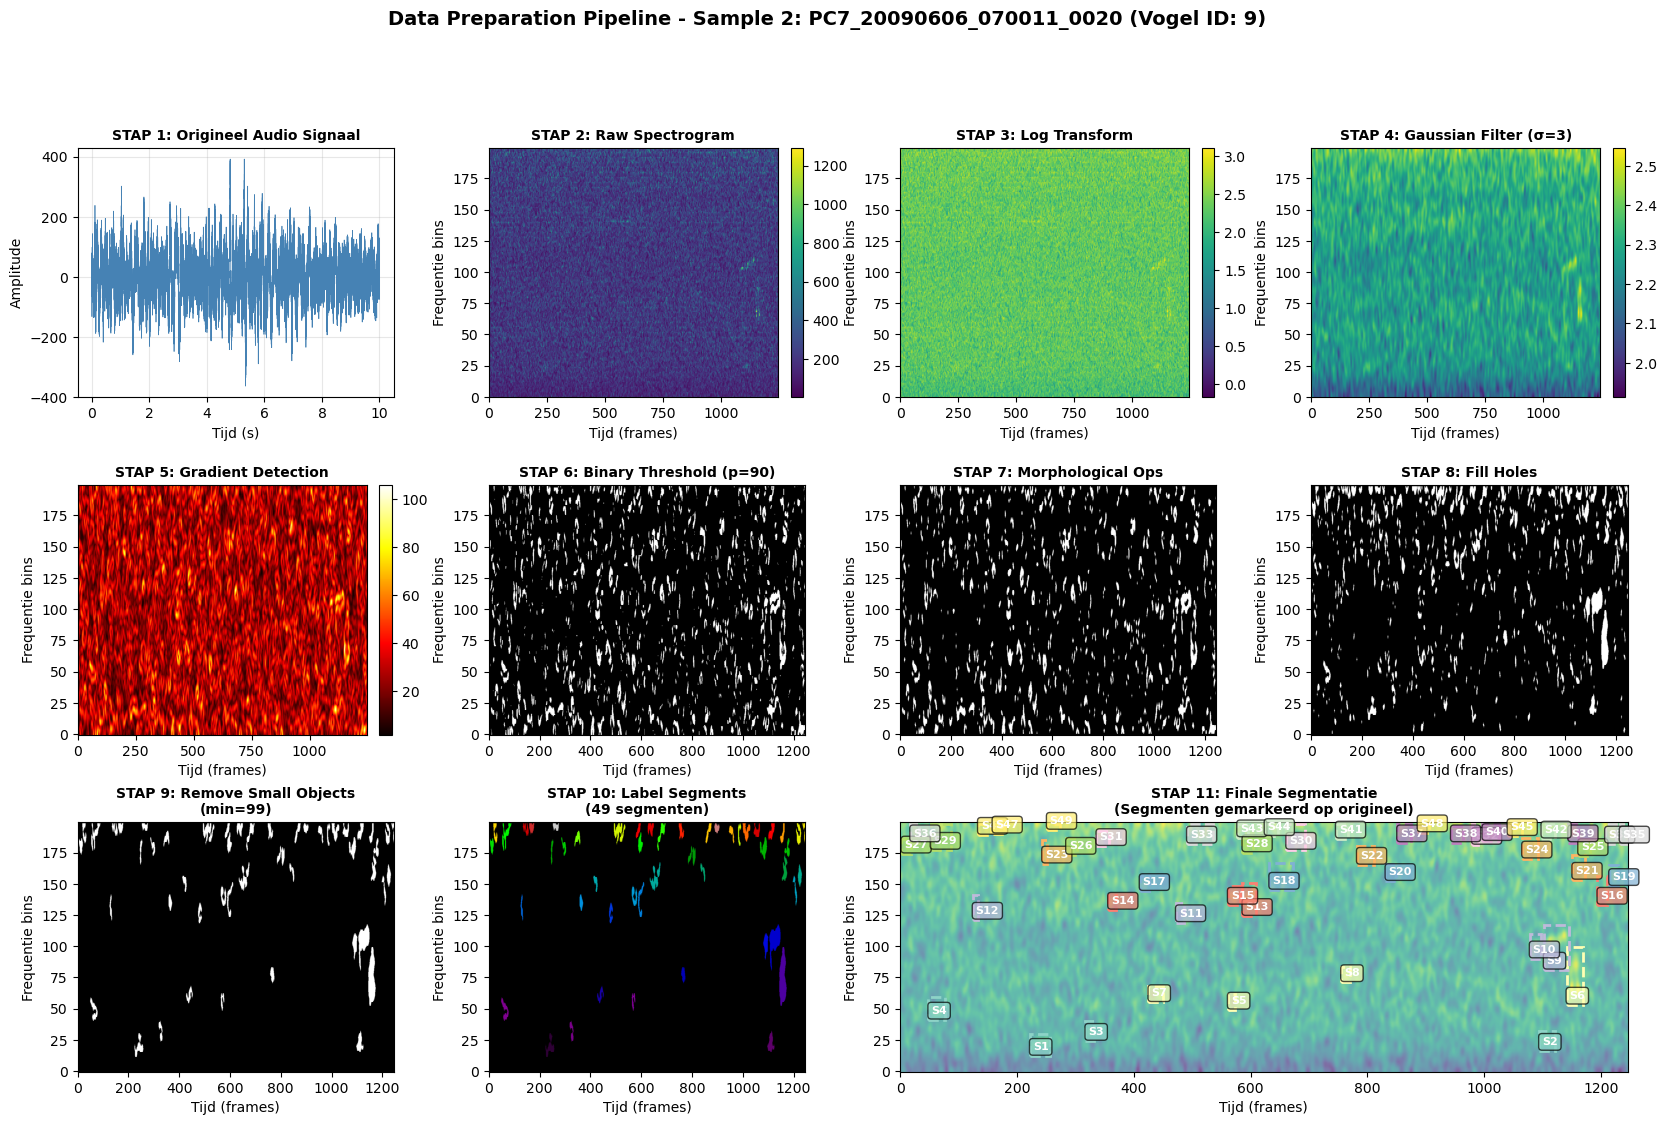


Segment Details:
  Segment 1: Positie=(222-256, 12-30), Grootte=(34x18), Area=612 pixels
  Segment 2: Positie=(1094-1121, 16-32), Grootte=(27x16), Area=432 pixels
  Segment 3: Positie=(317-331, 24-40), Grootte=(14x16), Area=224 pixels
  Segment 4: Positie=(48-76, 41-59), Grootte=(28x18), Area=504 pixels
  Segment 5: Positie=(561-574, 49-62), Grootte=(13x13), Area=169 pixels
  Segment 6: Positie=(1141-1169, 53-99), Grootte=(28x46), Area=1288 pixels
  Segment 7: Positie=(425-450, 55-68), Grootte=(25x13), Area=325 pixels
  Segment 8: Positie=(755-771, 71-83), Grootte=(16x12), Area=192 pixels
  Segment 9: Positie=(1102-1145, 81-117), Grootte=(43x36), Area=1548 pixels
  Segment 10: Positie=(1078-1097, 90-110), Grootte=(19x20), Area=380 pixels
  Segment 11: Positie=(472-486, 119-135), Grootte=(14x16), Area=224 pixels
  Segment 12: Positie=(124-133, 121-141), Grootte=(9x20), Area=180 pixels
  Segment 13: Positie=(586-609, 124-151), Grootte=(23x27), Area=621 pixels
  Segment 14: Positie=(356-

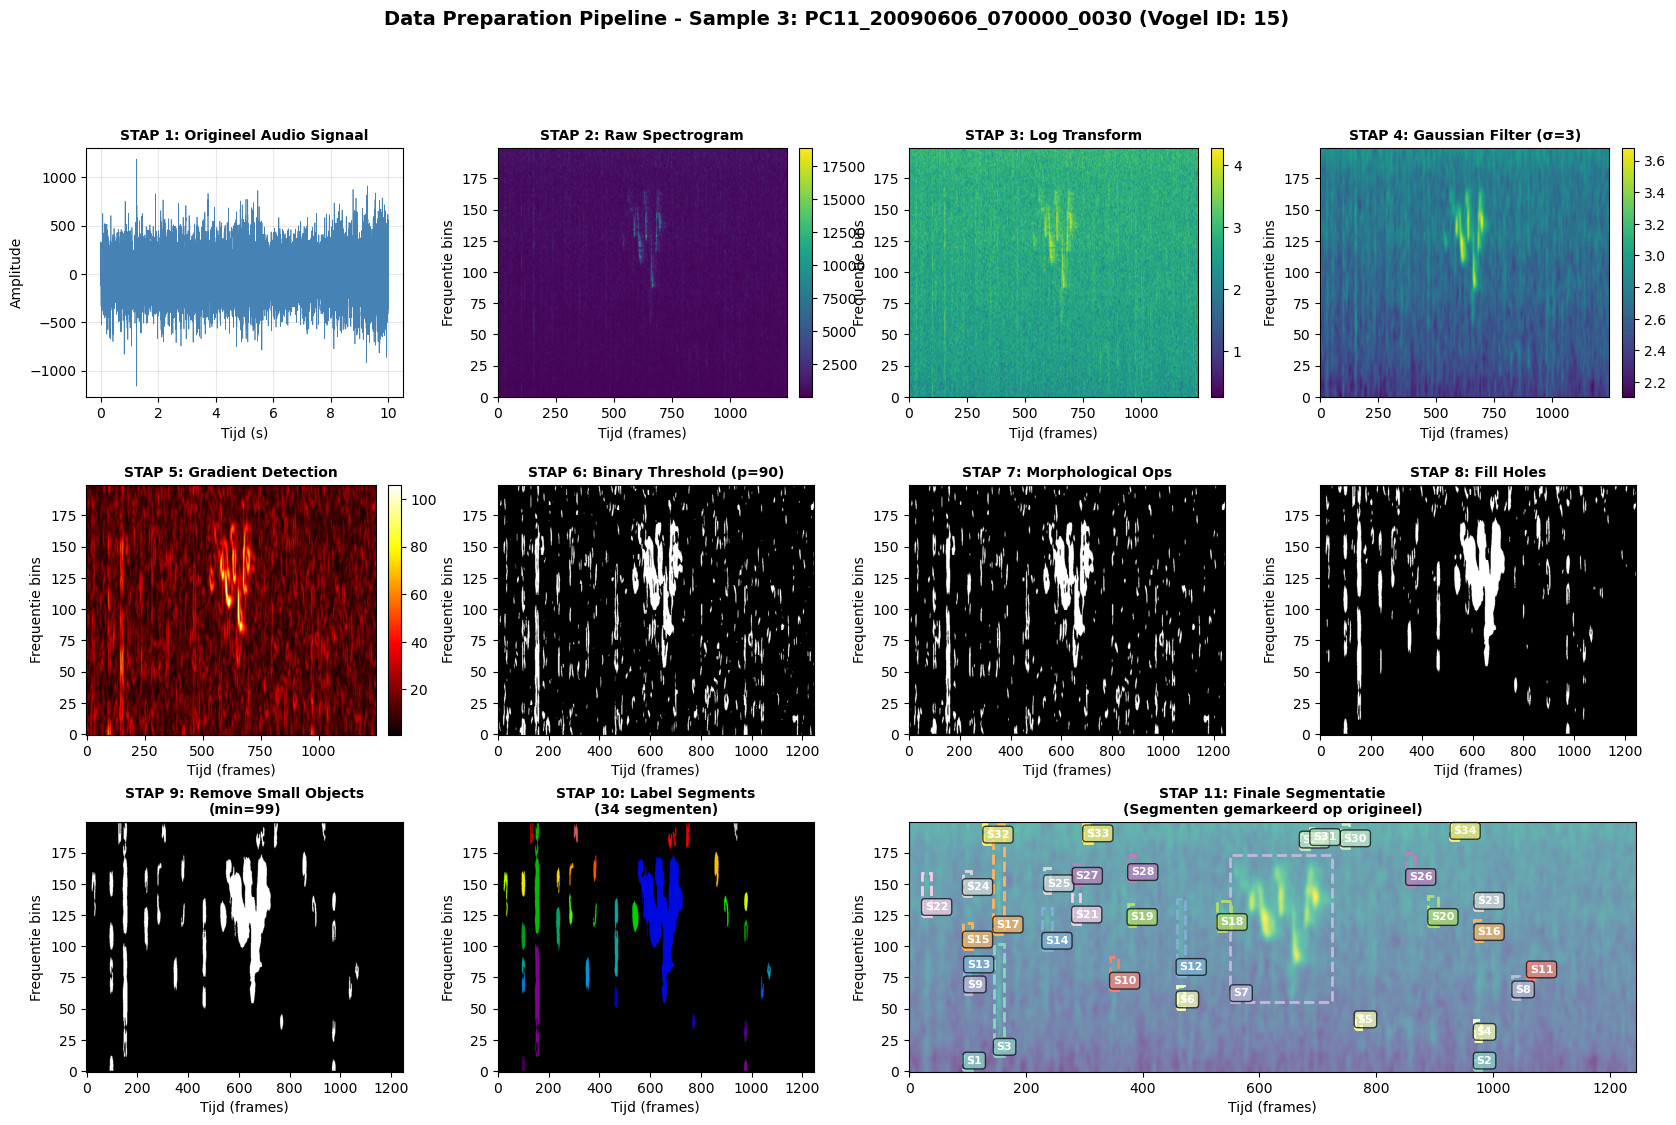


Segment Details:
  Segment 1: Positie=(93-107, 1-12), Grootte=(14x11), Area=154 pixels
  Segment 2: Positie=(967-980, 1-9), Grootte=(13x8), Area=104 pixels
  Segment 3: Positie=(145-162, 12-102), Grootte=(17x90), Area=1530 pixels
  Segment 4: Positie=(967-979, 24-41), Grootte=(12x17), Area=204 pixels
  Segment 5: Positie=(763-774, 34-45), Grootte=(11x11), Area=121 pixels
  Segment 6: Positie=(458-470, 50-68), Grootte=(12x18), Area=216 pixels
  Segment 7: Positie=(550-725, 55-173), Grootte=(175x118), Area=20650 pixels
  Segment 8: Positie=(1033-1044, 58-76), Grootte=(11x18), Area=198 pixels
  Segment 9: Positie=(94-106, 62-79), Grootte=(12x17), Area=204 pixels
  Segment 10: Positie=(344-358, 65-91), Grootte=(14x26), Area=364 pixels
  Segment 11: Positie=(1058-1071, 74-87), Grootte=(13x13), Area=169 pixels
  Segment 12: Positie=(458-472, 76-138), Grootte=(14x62), Area=868 pixels
  Segment 13: Positie=(94-105, 78-91), Grootte=(11x13), Area=143 pixels
  Segment 14: Positie=(228-244, 97-13

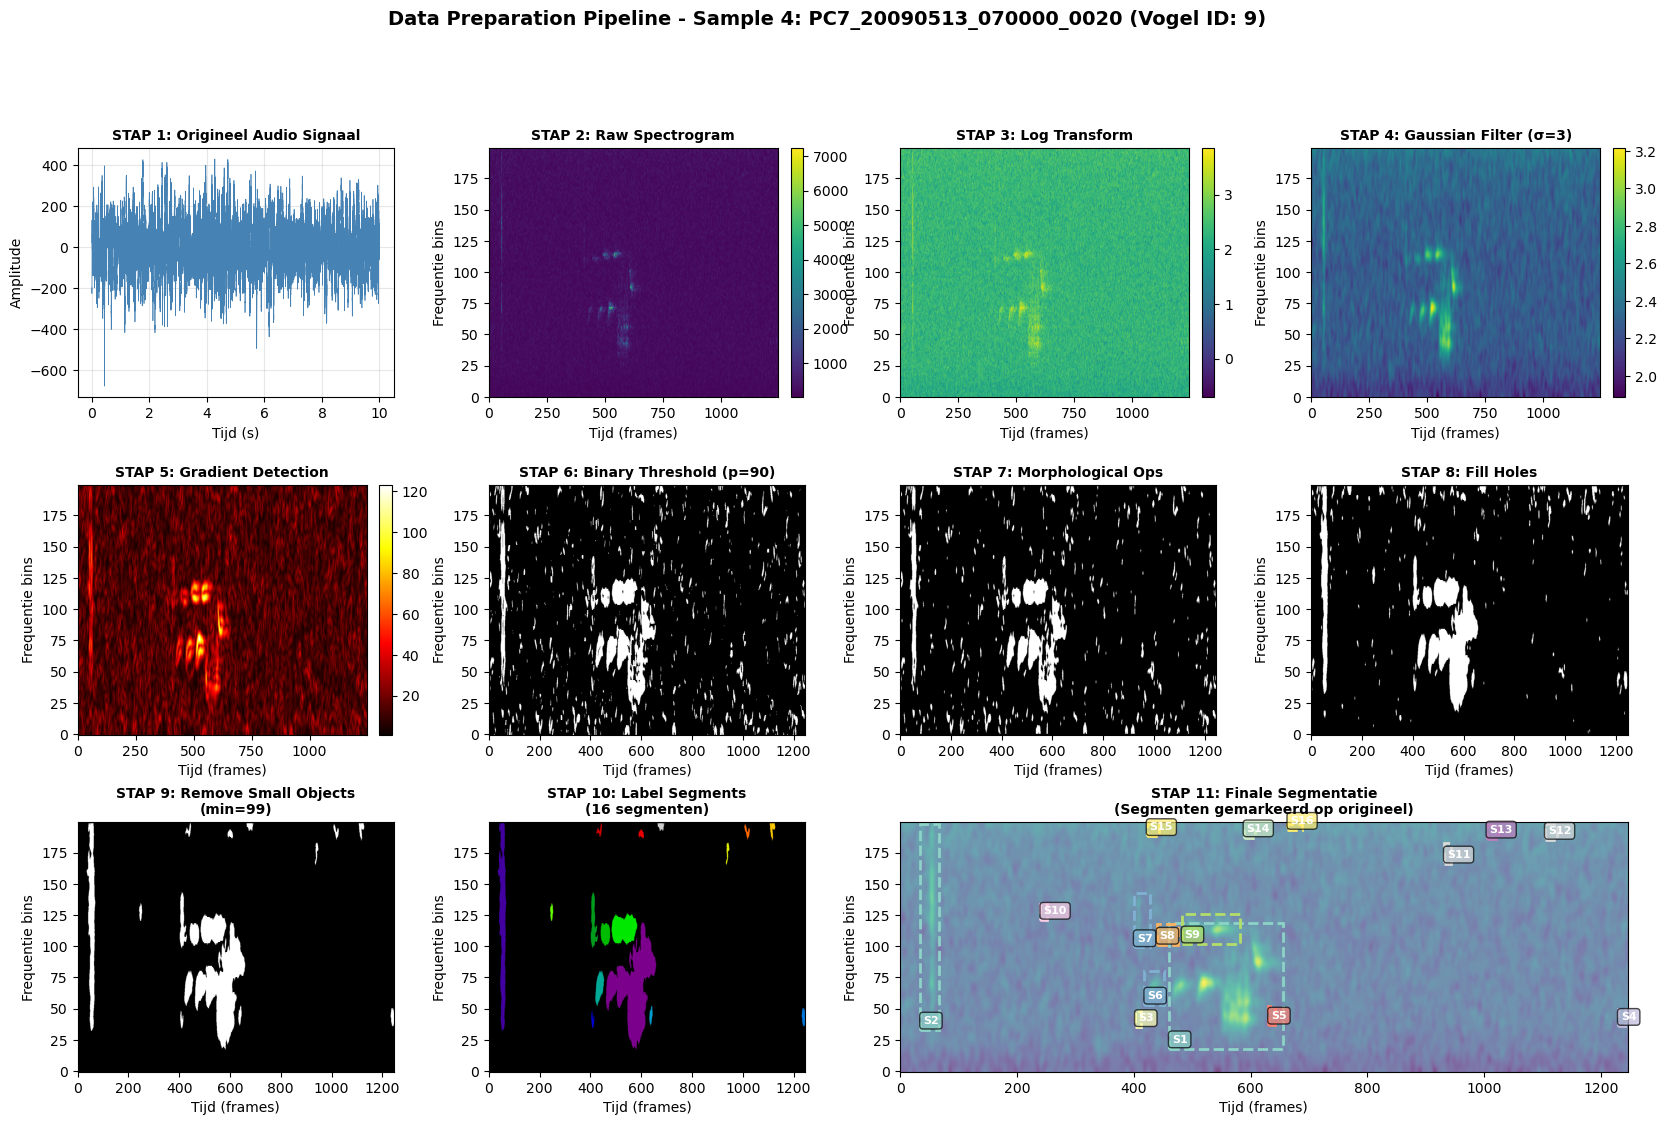


Segment Details:
  Segment 1: Positie=(460-656, 18-119), Grootte=(196x101), Area=19796 pixels
  Segment 2: Positie=(34-67, 33-198), Grootte=(33x165), Area=5445 pixels
  Segment 3: Positie=(402-413, 35-48), Grootte=(11x13), Area=143 pixels
  Segment 4: Positie=(1229-1242, 36-50), Grootte=(13x14), Area=182 pixels
  Segment 5: Positie=(630-642, 37-52), Grootte=(12x15), Area=180 pixels
  Segment 6: Positie=(418-452, 53-80), Grootte=(34x27), Area=918 pixels
  Segment 7: Positie=(400-427, 99-143), Grootte=(27x44), Area=1188 pixels
  Segment 8: Positie=(439-475, 101-118), Grootte=(36x17), Area=612 pixels
  Segment 9: Positie=(482-582, 102-126), Grootte=(100x24), Area=2400 pixels
  Segment 10: Positie=(240-251, 121-134), Grootte=(11x13), Area=143 pixels
  Segment 11: Positie=(931-944, 166-183), Grootte=(13x17), Area=221 pixels
  Segment 12: Positie=(1104-1124, 185-198), Grootte=(20x13), Area=260 pixels
  Segment 13: Positie=(1004-1024, 186-197), Grootte=(20x11), Area=220 pixels
  Segment 14: 

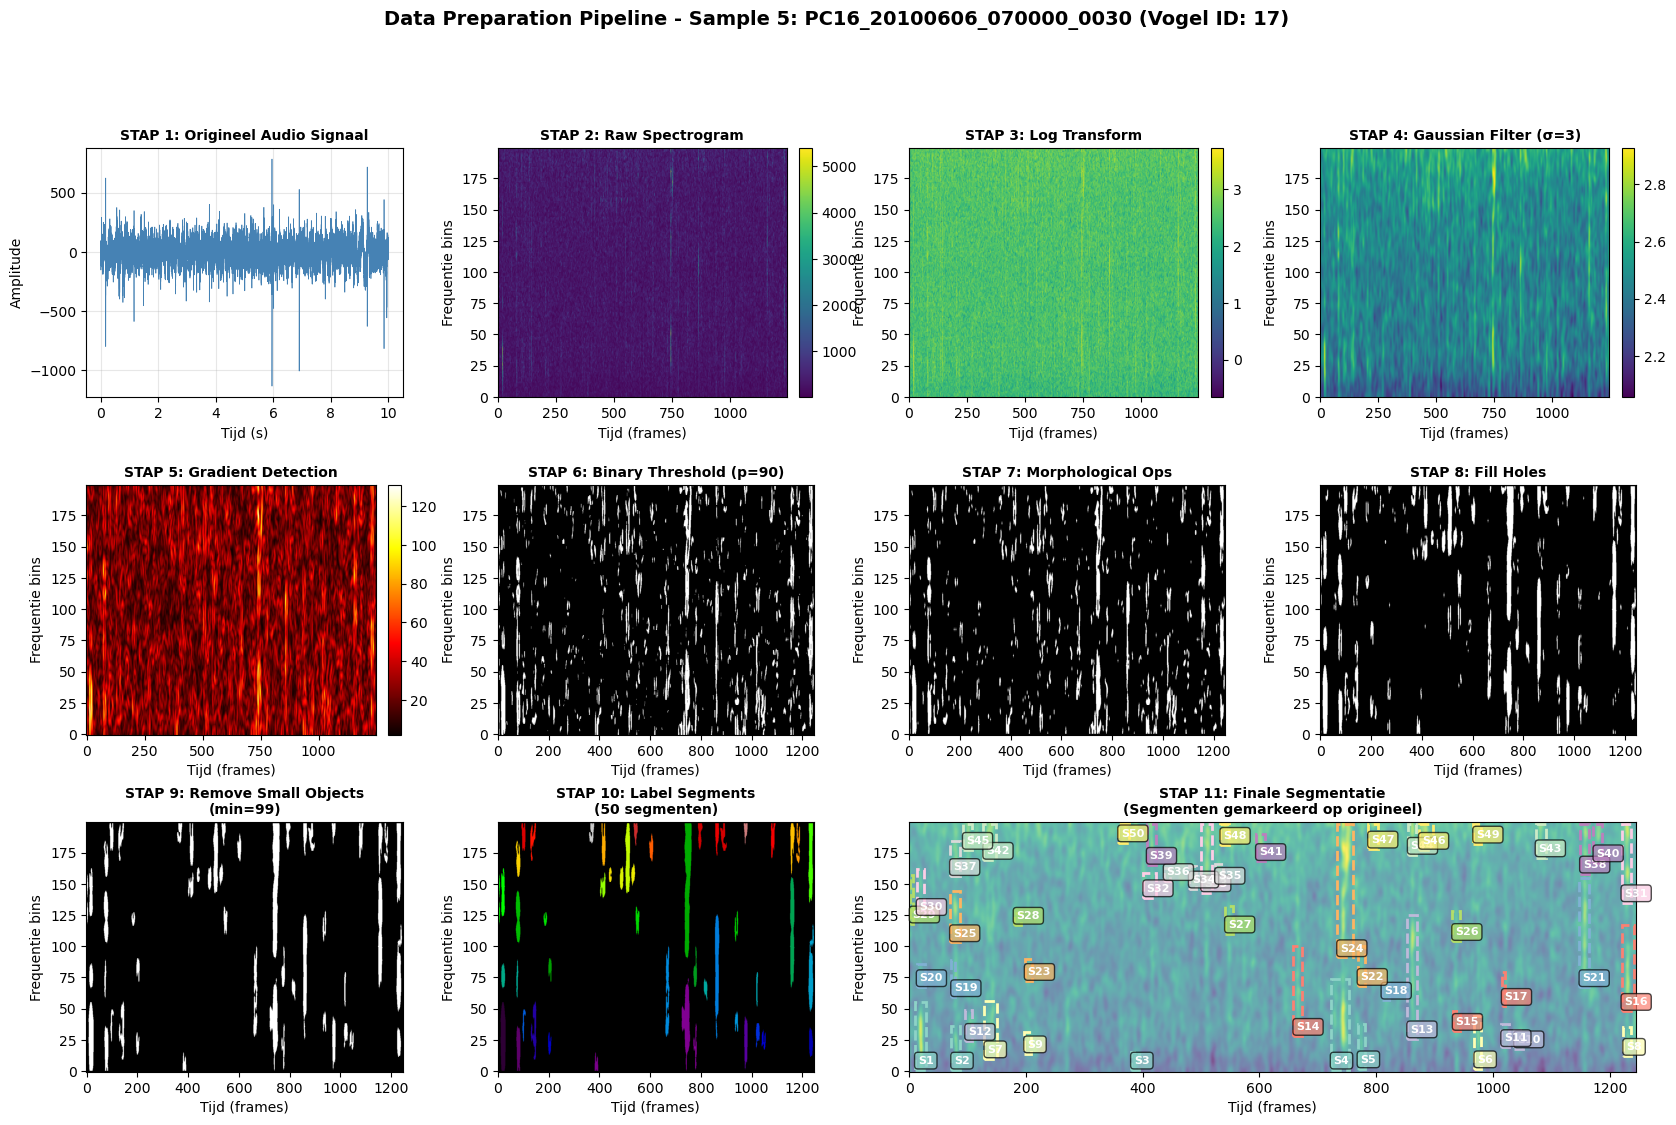


Segment Details:
  Segment 1: Positie=(10-29, 1-55), Grootte=(19x54), Area=1026 pixels
  Segment 2: Positie=(72-87, 1-36), Grootte=(15x35), Area=525 pixels
  Segment 3: Positie=(380-393, 1-15), Grootte=(13x14), Area=182 pixels
  Segment 4: Positie=(722-754, 1-74), Grootte=(32x73), Area=2336 pixels
  Segment 5: Positie=(768-780, 2-38), Grootte=(12x36), Area=432 pixels
  Segment 6: Positie=(968-980, 2-44), Grootte=(12x42), Area=504 pixels
  Segment 7: Positie=(129-150, 10-56), Grootte=(21x46), Area=966 pixels
  Segment 8: Positie=(1223-1237, 12-35), Grootte=(14x23), Area=322 pixels
  Segment 9: Positie=(197-209, 14-31), Grootte=(12x17), Area=204 pixels
  Segment 10: Positie=(1036-1051, 18-33), Grootte=(15x15), Area=225 pixels
  Segment 11: Positie=(1014-1028, 19-38), Grootte=(14x19), Area=266 pixels
  Segment 12: Positie=(96-108, 24-49), Grootte=(12x25), Area=300 pixels
  Segment 13: Positie=(853-869, 26-125), Grootte=(16x99), Area=1584 pixels
  Segment 14: Positie=(658-673, 28-100), Gr

Exception ignored in: <function ResourceTracker.__del__ at 0x7cbc77d8b9c0>
Traceback (most recent call last):
  File "/home/crabbedfish/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/crabbedfish/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/crabbedfish/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7706d738b9c0>
Traceback (most recent call last):
  File "/home/crabbedfish/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/crabbedfish/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/crabbedfish/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in

In [23]:
###################################################
## VISUALISATIE VAN DATA PREPARATION STAPPEN
## Per stap laten zien wat er gebeurt voor 5 test vogels
###################################################

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

# Selecteer 5 random training samples met 1 vogelsoort
single_bird_samples = label[(label.fold == 0) & (label[range(num_species)].sum(axis=1) == 1)]
sample_indices = np.random.choice(single_bird_samples.index, size=min(5, len(single_bird_samples)), replace=False)

print(f"Visualiseren van data preparation voor {len(sample_indices)} vogel samples\n")

for sample_num, file_idx in enumerate(sample_indices):
    print(f"\n{'='*80}")
    print(f"SAMPLE {sample_num + 1}/{len(sample_indices)} - File Index: {file_idx}")
    print(f"{'='*80}")
    
    # Get file info
    fname = label.iloc[file_idx]['filename']
    bird_spec = label.iloc[file_idx][range(num_species)].argmax()
    print(f"Bestand: {fname}")
    print(f"Vogelsoort ID: {bird_spec}")
    
    # Read audio
    S = wav_to_floats(essential_folder+'src_wavs/'+fname+'.wav')
    
    # Create spectrogram
    Spectogram = []
    for j in range(int(Step*N//K)-Step):
        vec = S[j * K//Step : (j+Step) * K//Step] * wind
        Spectogram.append(abs(fft(vec,K)[:K//2]))
    
    mypic = np.transpose(np.array(Spectogram))
    mypic_rev = np.flipud(mypic)
    mypic_rev_small = mypic_rev[:200,:]
    mypic_rev = mypic_rev_small
    
    # STAP 1: Log transform
    mypic_rev_log = np.log10(mypic_rev + 0.001)
    
    # STAP 2: Gaussian filtering
    mypic_rev_gauss = sp.ndimage.gaussian_filter(mypic_rev, sigma=3)
    mypic_rev_log_gauss = sp.ndimage.gaussian_filter(mypic_rev_log, sigma=3)
    
    # STAP 3: Gradient detection
    mypic_rev_gauss_grad = gradient(pic_to_ubyte(mypic_rev_gauss), disk(3))
    mypic_rev_log_gauss_grad = gradient(pic_to_ubyte(mypic_rev_log_gauss), disk(3))
    
    # STAP 4: Binary thresholding
    p = 90
    mypic_rev_gauss_grad_bin = mypic_rev_gauss_grad > np.percentile(mypic_rev_gauss_grad, p)
    mypic_rev_log_gauss_grad_bin = mypic_rev_log_gauss_grad > np.percentile(mypic_rev_log_gauss_grad, p)
    
    # STAP 5: Morphological operations
    mypic_rev_gauss_grad_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_gauss_grad_bin))
    mypic_rev_log_gauss_grad_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_log_gauss_grad_bin))
    
    # STAP 6: Fill holes en remove small objects
    bfh = sp.ndimage.binary_fill_holes(mypic_rev_gauss_grad_bin_close)
    bfh_rm = remove_small_objects(bfh, MIN_SEGMENT_SIZE)
    log_bfh = sp.ndimage.binary_fill_holes(mypic_rev_log_gauss_grad_bin_close)
    log_bfh_rm = remove_small_objects(log_bfh, MIN_SEGMENT_SIZE)
    
    # STAP 7: Extract segments
    labeled_segments, num_segments = sp.ndimage.label(bfh_rm)
    segment_bounds = []
    for seg_id in range(1, num_segments+1):
        current_segment = (labeled_segments == seg_id) * 1
        xr = current_segment.max(axis=0)
        yr = current_segment.max(axis=1)
        xr_max = np.max(xr * np.arange(len(xr)))
        xr[xr==0] = xr.shape[0]
        xr_min = np.argmin(xr)
        yr_max = np.max(yr * np.arange(len(yr)))
        yr[yr==0] = yr.shape[0]
        yr_min = np.argmin(yr)
        segment_bounds.append([yr_min, yr_max, xr_min, xr_max])
    
    print(f"Aantal gedetecteerde segmenten: {num_segments}")
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)
    
    # Row 1: Original signal and initial processing
    ax1 = fig.add_subplot(gs[0, 0])
    time = np.arange(len(S)) / 16000  # Sample rate 16kHz
    ax1.plot(time, S, linewidth=0.5, color='steelblue')
    ax1.set_title('STAP 1: Origineel Audio Signaal', fontsize=10, fontweight='bold')
    ax1.set_xlabel('Tijd (s)')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True, alpha=0.3)
    
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(mypic_rev, aspect='auto', origin='lower', cmap='viridis')
    ax2.set_title('STAP 2: Raw Spectrogram', fontsize=10, fontweight='bold')
    ax2.set_xlabel('Tijd (frames)')
    ax2.set_ylabel('Frequentie bins')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    ax3 = fig.add_subplot(gs[0, 2])
    im3 = ax3.imshow(mypic_rev_log, aspect='auto', origin='lower', cmap='viridis')
    ax3.set_title('STAP 3: Log Transform', fontsize=10, fontweight='bold')
    ax3.set_xlabel('Tijd (frames)')
    ax3.set_ylabel('Frequentie bins')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
    
    ax4 = fig.add_subplot(gs[0, 3])
    im4 = ax4.imshow(mypic_rev_log_gauss, aspect='auto', origin='lower', cmap='viridis')
    ax4.set_title('STAP 4: Gaussian Filter (σ=3)', fontsize=10, fontweight='bold')
    ax4.set_xlabel('Tijd (frames)')
    ax4.set_ylabel('Frequentie bins')
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
    
    # Row 2: Gradient and binary processing
    ax5 = fig.add_subplot(gs[1, 0])
    im5 = ax5.imshow(mypic_rev_log_gauss_grad, aspect='auto', origin='lower', cmap='hot')
    ax5.set_title('STAP 5: Gradient Detection', fontsize=10, fontweight='bold')
    ax5.set_xlabel('Tijd (frames)')
    ax5.set_ylabel('Frequentie bins')
    plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)
    
    ax6 = fig.add_subplot(gs[1, 1])
    ax6.imshow(mypic_rev_log_gauss_grad_bin, aspect='auto', origin='lower', cmap='gray')
    ax6.set_title('STAP 6: Binary Threshold (p=90)', fontsize=10, fontweight='bold')
    ax6.set_xlabel('Tijd (frames)')
    ax6.set_ylabel('Frequentie bins')
    
    ax7 = fig.add_subplot(gs[1, 2])
    ax7.imshow(mypic_rev_log_gauss_grad_bin_close, aspect='auto', origin='lower', cmap='gray')
    ax7.set_title('STAP 7: Morphological Ops', fontsize=10, fontweight='bold')
    ax7.set_xlabel('Tijd (frames)')
    ax7.set_ylabel('Frequentie bins')
    
    ax8 = fig.add_subplot(gs[1, 3])
    ax8.imshow(bfh, aspect='auto', origin='lower', cmap='gray')
    ax8.set_title('STAP 8: Fill Holes', fontsize=10, fontweight='bold')
    ax8.set_xlabel('Tijd (frames)')
    ax8.set_ylabel('Frequentie bins')
    
    # Row 3: Final segmentation results
    ax9 = fig.add_subplot(gs[2, 0])
    ax9.imshow(bfh_rm, aspect='auto', origin='lower', cmap='gray')
    ax9.set_title(f'STAP 9: Remove Small Objects\n(min={MIN_SEGMENT_SIZE})', fontsize=10, fontweight='bold')
    ax9.set_xlabel('Tijd (frames)')
    ax9.set_ylabel('Frequentie bins')
    
    ax10 = fig.add_subplot(gs[2, 1])
    ax10.imshow(labeled_segments, aspect='auto', origin='lower', cmap='nipy_spectral')
    ax10.set_title(f'STAP 10: Label Segments\n({num_segments} segmenten)', fontsize=10, fontweight='bold')
    ax10.set_xlabel('Tijd (frames)')
    ax10.set_ylabel('Frequentie bins')
    
    ax11 = fig.add_subplot(gs[2, 2:])
    ax11.imshow(mypic_rev_log_gauss, aspect='auto', origin='lower', cmap='viridis', alpha=0.7)
    ax11.set_title(f'STAP 11: Finale Segmentatie\n(Segmenten gemarkeerd op origineel)', fontsize=10, fontweight='bold')
    ax11.set_xlabel('Tijd (frames)')
    ax11.set_ylabel('Frequentie bins')
    
    # Draw segment boundaries
    colors = plt.cm.Set3(np.linspace(0, 1, len(segment_bounds)))
    for idx, (y_min, y_max, x_min, x_max) in enumerate(segment_bounds):
        rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, 
                                 linewidth=2, edgecolor=colors[idx], 
                                 facecolor='none', linestyle='--')
        ax11.add_patch(rect)
        # Add segment number
        ax11.text(x_min + 5, y_min + 5, f'S{idx+1}', 
                 color='white', fontsize=8, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[idx], alpha=0.7))
    
    plt.suptitle(f'Data Preparation Pipeline - Sample {sample_num+1}: {fname} (Vogel ID: {bird_spec})', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    plt.savefig(f'{log_folder}data_prep_visualization_sample_{sample_num+1}.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print segment statistics
    print(f"\nSegment Details:")
    for idx, (y_min, y_max, x_min, x_max) in enumerate(segment_bounds):
        width = x_max - x_min
        height = y_max - y_min
        area = width * height
        print(f"  Segment {idx+1}: Positie=({x_min}-{x_max}, {y_min}-{y_max}), "
              f"Grootte=({width}x{height}), Area={area} pixels")

print(f"\n{'='*80}")
print("VISUALISATIE COMPLEET!")
print(f"Afbeeldingen opgeslagen in: {log_folder}")
print(f"{'='*80}")